C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0525 - mae: 0.1754 - mse: 0.0525 - val_loss: 0.0280 - val_mae: 0.1306 - val_mse: 0.0280
Epoch 2/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0300 - mae: 0.1338 - mse: 0.0300 - val_loss: 0.0277 - val_mae: 0.1311 - val_mse: 0.0277
Epoch 3/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0285 - mae: 0.1298 - mse: 0.0285 - val_loss: 0.0287 - val_mae: 0.1325 - val_mse: 0.0287
Epoch 4/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0283 - mae: 0.1296 - mse: 0.0283 - val_loss: 0.0264 - val_mae: 0.1254 - val_mse: 0.0264
Epoch 5/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0282 - mae: 0.1288 - mse: 0.0282 - val_loss: 0.0270 - val_mae: 0.1253 - val_mse: 0.0270
Epoch 6/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0272 - mae: 0.1259 - mse: 0.0272 - val_loss: 0.0269 - val_mae: 0.1293 - val_mse: 0.0269
Epoch 7/20
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0271 - mae: 0.1264 - mse: 0.0271 - v

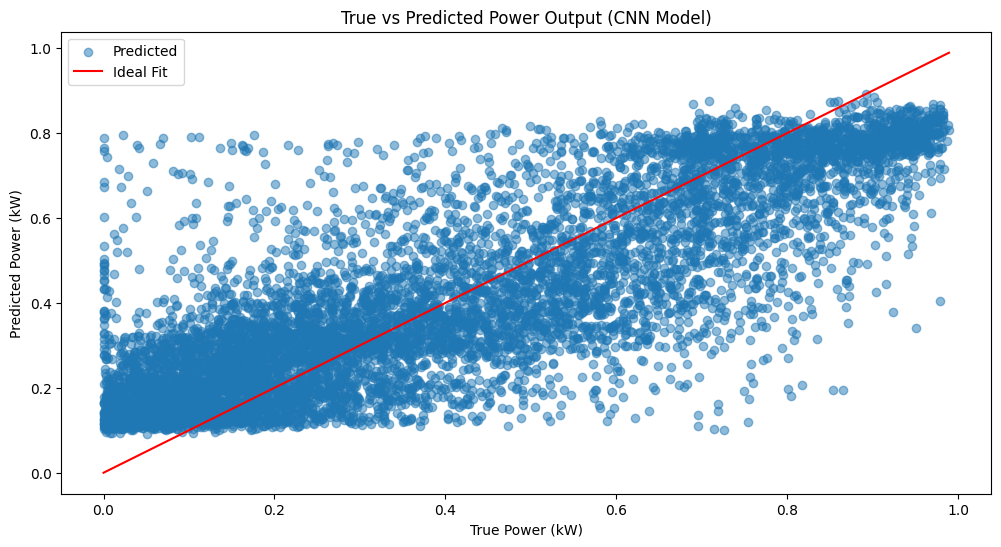

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

data = pd.read_csv('Location1.csv')
data['Time'] = pd.to_datetime(data['Time'])
data['hour'] = data['Time'].dt.hour
data['day_of_week'] = data['Time'].dt.dayofweek
data['month'] = data['Time'].dt.month

features = [
    'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 
    'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 
    'winddirection_100m', 'windgusts_10m', 'hour', 'day_of_week', 'month'
]
target = 'Power'

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

joblib.dump(scaler_y, 'scaler_y.pkl')

X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  
])

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

# Train the model
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

loss, mae, mse = model.evaluate(X_test_scaled, y_test_scaled)
print(f"Test Loss: {loss}, Test MAE: {mae}, Test MSE: {mse}")

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

model.save('CNN.keras')


results = pd.DataFrame({
    'True Power (kW)': y_test.values,
    'Predicted Power (kW)': y_pred.flatten()
})


plt.figure(figsize=(12, 6))
plt.scatter(results['True Power (kW)'], results['Predicted Power (kW)'], alpha=0.5, label='Predicted')
plt.plot([results['True Power (kW)'].min(), results['True Power (kW)'].max()],
         [results['True Power (kW)'].min(), results['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output (CNN Model)')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()


In [2]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.6985092437438725